<a href="https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatVTON basic front inference example

In [1]:
# Клонируем репозиторий CatVTON
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 17.01 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [2]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

# Обновляем accelerate до последней версии (>=0.32.0) и ставим стабильный diffusers
!pip install -U accelerate diffusers==0.30.3 peft huggingface_hub

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-e75blgtx
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-e75blgtx
  Resolved https://github.com/huggingface/diffusers.git to commit d773308ca726766d6d2867f1fb8732df3d1dc5a3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 40.4 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/lib/python3.12/pathlib.py", line 441, in __str__
^C


In [2]:
# Clean up existing conflicting installations first
!pip uninstall -y torch torchvision torchaudio xformers

# Устанавливаем PyTorch 2.4.0 (CUDA 12.4) и совместимую версию xformers
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu124
!pip install xformers==0.0.27.post2

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: xformers 0.0.35
Uninstalling xformers-0.0.35:
  Successfully uninstalled xformers-0.0.35
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 142.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 125.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 68.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 62.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 124.5 MB/s eta 0:00:00


In [1]:
!nvcc --version

import torch
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
PyTorch version: 2.4.0+cu124
PyTorch CUDA version: 12.4


In [2]:
import urllib.request

# test human-model image (front view)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/person/men/model_5.png",
    "person.png"
)

# test garment image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/condition/upper/24083449_54173465_2048.jpg",
    "garment.jpg"
)

('garment.jpg', <http.client.HTTPMessage at 0x7fa6d1f40d10>)

In [3]:
%cd CatVTON

/content/CatVTON


In [4]:
%ls

app_flux.py  detectron2/   LICENSE                      README.md
app_p2p.py   eval.py       model/                       requirements.txt
app.py       index.html    preprocess_agnostic_mask.py  resource/
densepose/   inference.py  __pycache__/                 utils.py


In [5]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

/usr/local/lib/python3.12/dist-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/usr/local/lib/python3.12/dist-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/xformers/__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/triton/__init__.py", line 8, in <module>
    from .runtime import (
  File "/usr/local/lib/python3.12/dist-packages/tri

RuntimeError: Failed to import diffusers.models.autoencoders.autoencoder_kl because of the following error (look up to see its traceback):
infer_schema(func): Parameter q has unsupported type torch.Tensor. The valid types are: dict_keys([<class 'torch.Tensor'>, typing.Optional[torch.Tensor], typing.Sequence[torch.Tensor], typing.List[torch.Tensor], typing.Sequence[typing.Optional[torch.Tensor]], typing.List[typing.Optional[torch.Tensor]], <class 'int'>, typing.Optional[int], typing.Sequence[int], typing.List[int], typing.Optional[typing.Sequence[int]], typing.Optional[typing.List[int]], <class 'float'>, typing.Optional[float], typing.Sequence[float], typing.List[float], typing.Optional[typing.Sequence[float]], typing.Optional[typing.List[float]], <class 'bool'>, typing.Optional[bool], typing.Sequence[bool], typing.List[bool], typing.Optional[typing.Sequence[bool]], typing.Optional[typing.List[bool]], <class 'str'>, typing.Optional[str], typing.Union[int, float, bool], typing.Union[int,

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

README.md: 0.00B [00:00, ?B/s]

mix-48k-1024/attention/model.safetensors:   0%|          | 0.00/198M [00:00<?, ?B/s]

flux-lora/pytorch_lora_weights.safetenso(…):   0%|          | 0.00/37.4M [00:00<?, ?B/s]

vitonhd-16k-512/attention/model.safetens(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [ ]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


## Example inference on front view

In [ ]:
# Clear memory before running
torch.cuda.empty_cache()
gc.collect()

# 1. Load images
person_path = "/content/person.png"
garment_path = "/content/garment.jpg"

person_image = Image.open(person_path).convert("RGB")
garment_image = Image.open(garment_path).convert("RGB")

# Reduce resolution to 512x768 to avoid OOM on the free T4 GPU
target_size = (512, 768)
person_image = person_image.resize(target_size)
garment_image = garment_image.resize(target_size)

# 2. Generate mask
print("Generating mask...")
mask_result = automasker(person_image)
mask = mask_result['mask']

# 3. Clean up the patches (we are back to a standard KL VAE, so we need original functions)
import utils
import model.pipeline
import importlib

# Reloading restores the default CatVTON behavior that works with AutoencoderKL
importlib.reload(utils)
importlib.reload(model.pipeline)

# 4. Run inference
print("Running inference (try-on). This may take a couple of minutes...")
result_image = pipeline(
    image=person_image,
    condition_image=garment_image,
    mask=mask,
    num_inference_steps=50,
    guidance_scale=2.5
)[0]

Generating mask...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Running inference (try-on). This may take a couple of minutes...


100%|██████████| 50/50 [00:24<00:00,  2.04it/s]


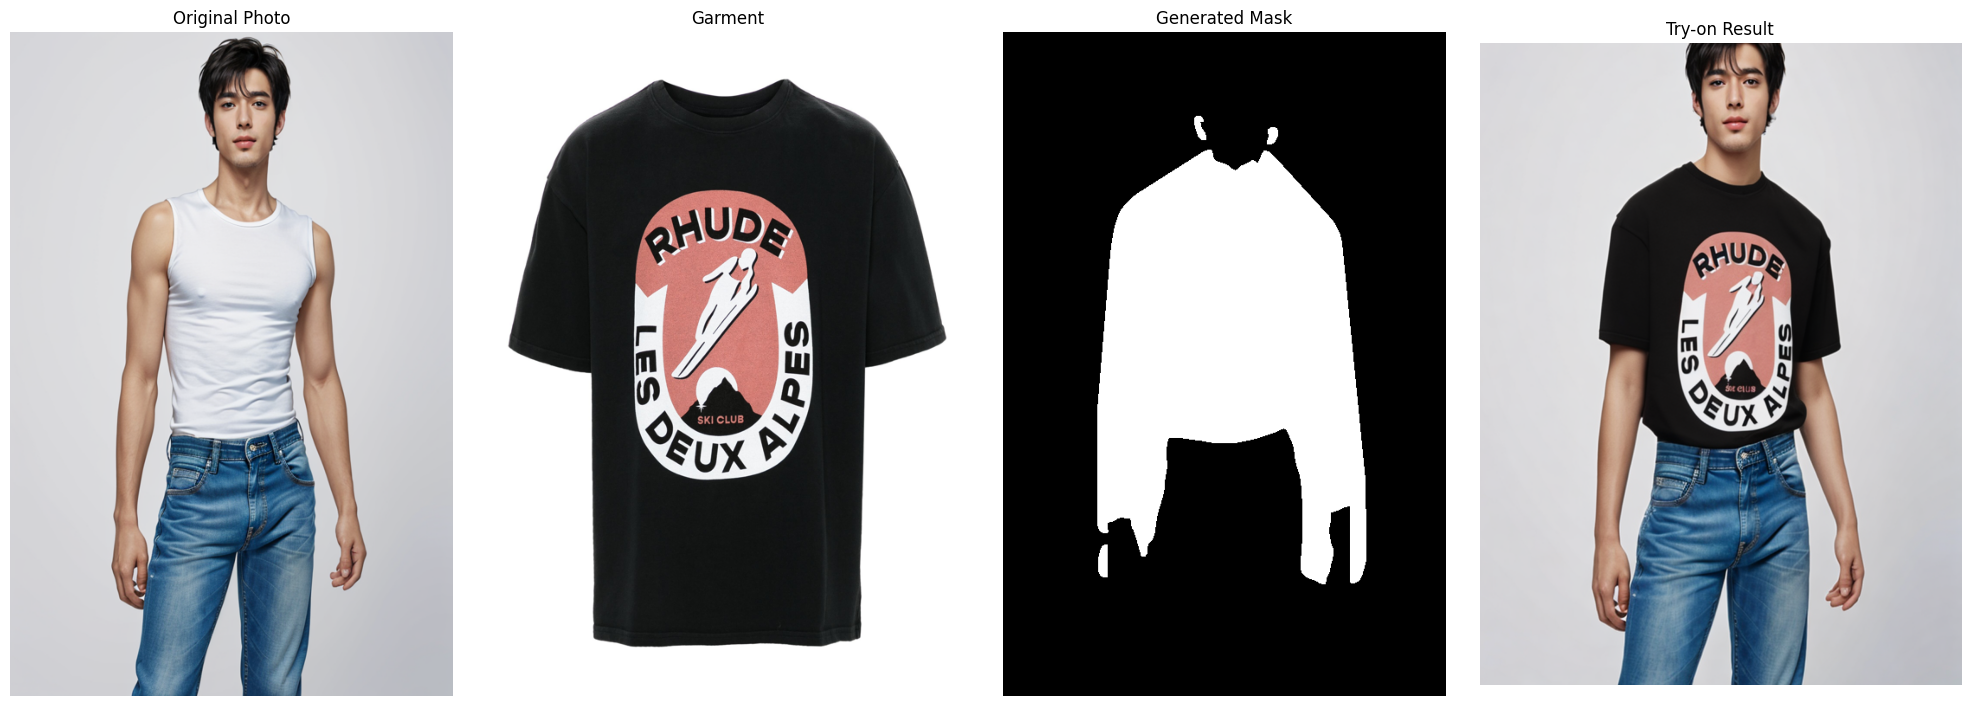

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 7))

axs[0].imshow(person_image)
axs[0].set_title("Original Photo")
axs[0].axis('off')

axs[1].imshow(garment_image)
axs[1].set_title("Garment")
axs[1].axis('off')

axs[2].imshow(mask, cmap='gray')
axs[2].set_title("Generated Mask")
axs[2].axis('off')

axs[3].imshow(result_image)
axs[3].set_title("Try-on Result")
axs[3].axis('off')

plt.tight_layout()
plt.show()

# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

In [ ]:
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        # Store K and V for each attention layer separately using their object ID
        self.reference_k = {}
        self.reference_v = {}
        self.is_reference_pass = False # Flag: generating reference (front) or target view?

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        batch_size, sequence_length, _ = hidden_states.shape

        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        # Transform dimensions to 4D for Flash Attention: (batch, heads, seq_len, head_dim)
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        layer_id = id(attn)

        # 2. Reference-Driven Editing Logic
        if self.is_reference_pass:
            # If this is the front view, save K and V for THIS specific layer
            self.reference_k[layer_id] = key.clone().detach()
            self.reference_v[layer_id] = value.clone().detach()
        else:
            # If this is a side/back view, APPEND the saved K and V
            ref_k = self.reference_k.get(layer_id)
            ref_v = self.reference_v.get(layer_id)

            if ref_k is not None and ref_v is not None:
                # Handle batch mismatch (due to Classifier-Free Guidance)
                if ref_k.shape[0] != key.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)

                # Concatenate along the spatial dimension (dim=2 in 4D tensor)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

        # 3. Memory-efficient Attention computation (SDPA)
        # Using 4D tensors enables memory-efficient / Flash Attention in PyTorch
        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False
                )
            except RuntimeError:
                # Fallback to math if necessary
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True, enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False
                    )

        # Reshape back to expected format
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---

# 1. Create an instance of our processor
ref_attn_processor = ReferenceAttentionProcessor()

# 2. Replace standard attention layers in U-Net with our custom one.
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    if "attn1" in name:
        attn_processors[name] = ref_attn_processor
    else:
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)
print("Success: Custom Reference Attention Processor (with FlashAttention fix) integrated into U-Net!")


Success: Custom Reference Attention Processor (with FlashAttention fix) integrated into U-Net!


### Testing Reference-Driven Editing (View Consistency)

For this test, we use `person.png` as the front view (reference) and a new image `person_side.png` as the side view.
*Please make sure you have uploaded `person_side.png` to Colab before running the code below.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Alternative to mounting google drive: upload only few necessary files from local computer
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
# Image paths in Tim's google drive
person_folder = "/content/drive/MyDrive/weavella/images/Photos_Manual_Selection/1"

front_person_path = person_folder + "/IMG_6508.JPG"
# side_person_path  = person_folder + "/IMG_6518.JPG"
side_person_path  = person_folder + "/IMG_6529.JPG"

# Load, rotate 90 degrees, and resize
target_size = (512, 768)
front_person_img = Image.open(front_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)
side_person_img = Image.open(side_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)


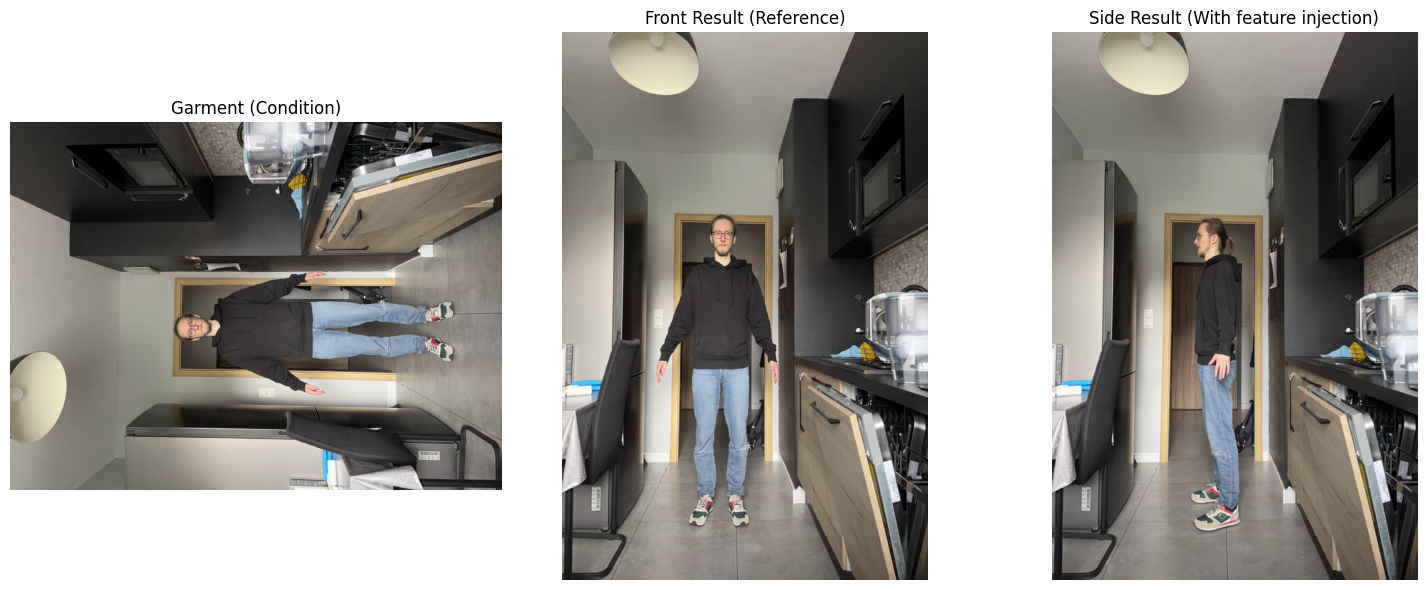

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(Image.open(front_person_path).convert("RGB"))
axs[0].set_title("Garment (Condition)")
axs[0].axis('off')

axs[1].imshow(front_person_img)
axs[1].set_title("Front Result (Reference)")
axs[1].axis('off')

axs[2].imshow(side_person_img)
axs[2].set_title("Side Result (With feature injection)")
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

print("Generating mask for side view...")
side_mask = automasker(side_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("\n--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
ref_attn_processor.is_reference_pass = True
front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=30,
    guidance_scale=2.5,
    generator=generator
)[0]

print("\n--- PASS 2: Target View Generation (Side) ---")
# Tell processor to use saved features
ref_attn_processor.is_reference_pass = False
side_result = pipeline(
    image=side_person_img,
    condition_image=garment_image,
    mask=side_mask,
    num_inference_steps=30,
    guidance_scale=2.5,
    generator=generator
)[0]

Generating mask for front view...
Generating mask for side view...

--- PASS 1: Reference Generation (Front) ---


  0%|          | 0/30 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 30/30 [00:15<00:00,  1.93it/s]



--- PASS 2: Target View Generation (Side) ---


100%|██████████| 30/30 [00:23<00:00,  1.30it/s]


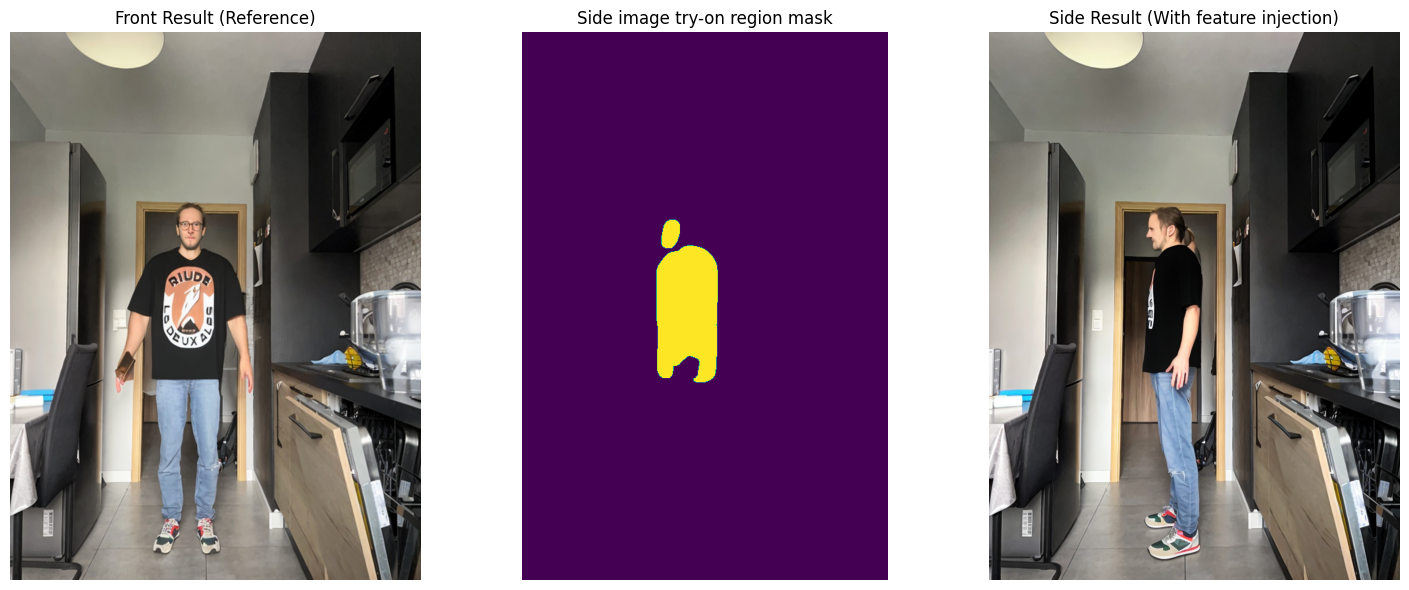

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(front_result)
axs[0].set_title("Front Result (Reference)")
axs[0].axis('off')

axs[1].imshow(side_mask)
axs[1].set_title("Side image try-on region mask")
axs[1].axis('off')

axs[2].imshow(side_result)
axs[2].set_title("Side Result (With feature injection)")
axs[2].axis('off')

plt.tight_layout()
plt.show()

# Complete pipeline test on vadim video

In [ ]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 35.70 MiB/s, done.
Resolving deltas: 100% (346/346), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 171), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [ ]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [ ]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.5/819.5 kB 29.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 51.0.0
    Uninstalling setuptools-51.0.0:
      Successfully uninstalled setuptools-51.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

  Preparing metadata (setup.py) ... done


In [ ]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [ ]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

/content/gaussian-splatting
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3074951 sha256=88347607efe6fb78cd5c7fb5e06b59b1834b763708ca8c6ee51a57ddb1ab2e01
  Stored in directory: /root/.cache/pip/wheels/0a/f2/1b/255828ebad94ea248378281b7926639d83ce4f394f0052800d
Successfully built simple_knn


In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim
!cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/input/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# All of these is to use GPU-accelerated version of COLMAP

# Install xvfb for OpenGL virtual display and required dependencies to build COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb cmake ninja-build \
    libboost-program-options-dev libboost-filesystem-dev libboost-graph-dev \
    libboost-system-dev libboost-test-dev libsuitesparse-dev \
    libfreeimage-dev libgoogle-glog-dev libgflags-dev \
    libglew-dev libqt5opengl5-dev qt5-qmake qtbase5-dev libceres-dev \
    libflann-dev libcgal-dev libmetis-dev

# Build COLMAP from source for GPU (CUDA) support
!rm -rf /content/colmap
!git clone --branch 3.9 https://github.com/colmap/colmap.git /content/colmap
%cd /content/colmap
!mkdir build
%cd build
!cmake .. -GNinja -DCUDA_ENABLED=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=native
!ninja
!sudo ninja install

# Return to the gaussian-splatting directory
%cd /content/gaussian-splatting

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [91.2 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,615 kB]
Get:13 http://security.ubuntu.com/ubun

In [ ]:
# Image paths in Tim's google drive
person_folder = "/content/gaussian-splatting/input/vadim/input"

front_person_path = person_folder + "/0012.jpg"

side_person_path  = person_folder + "/0001.jpg"

# Load, rotate 90 degrees, and resize
target_size = (512, 768)
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)

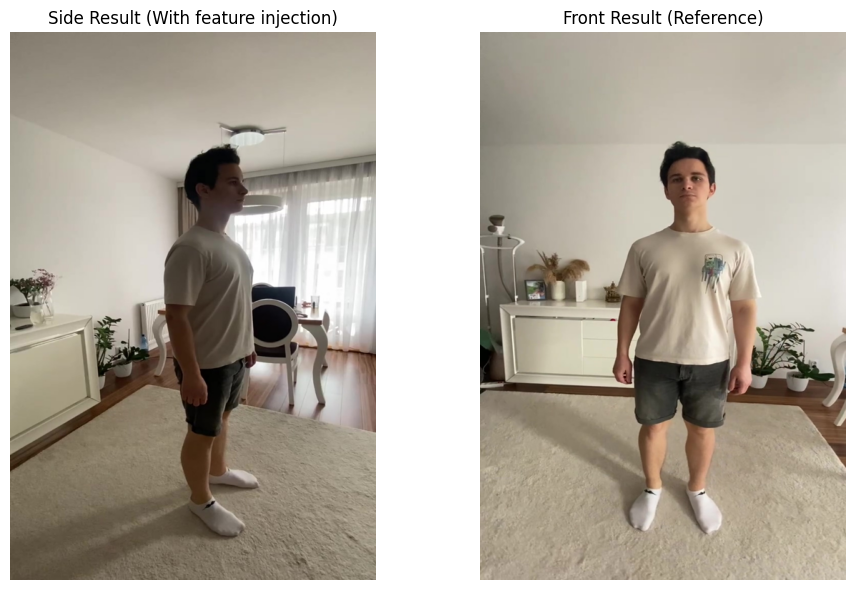

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 6))


axs[1].imshow(front_person_img)
axs[1].set_title("Front Result (Reference)")
axs[1].axis('off')

axs[0].imshow(side_person_img)
axs[0].set_title("Side Result (With feature injection)")
axs[0].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os


output_folder = "/content/gaussian-splatting/input/vadim/input_try-oned"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']
# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
ref_attn_processor.is_reference_pass = True
front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=30,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(front_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved front result to: {front_output_path}")

Generating mask for front view...


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]
side_person_paths = [f for f in all_files if os.path.abspath(f) != os.path.abspath(front_person_path)]

print("--- PASS 2: Target View Generation (Side) ---")
for side_person_path in side_person_paths:
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Tell processor to use saved features
    ref_attn_processor.is_reference_pass = False
    side_result = pipeline(
        image=side_person_img,
        condition_image=garment_image,
        mask=side_mask,
        num_inference_steps=30,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

## Run 3DGS training

In [ ]:
# Run COLMAP conversion using xvfb-run to allow OpenGL context creation
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim

In [ ]:
!python train.py -s /content/gaussian-splatting/input/vadim

In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/97327669-e /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_splat